# **Breast Cancer Prediction** | 2025

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

Yang perlu dilakuin :
- memprediksi apakah tumor ini ganas (M) atau jinak (B)
- kolom id bisa dihapus > karena ga relevan buat di prediksi
- kolom diagnosis itu perlu di ubah ke 0/1
- pastikan gaada NaN

## ***B. Import Libraries***

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tkinter as tk

## ***C. Import Dataset***

In [3]:
dataset = pd.read_csv("breast-cancer.csv")
dataset

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


# **II. Data Preparation**

## ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [4]:
dataset.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

### 2. Inspeksi Informasi Ringkas

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

Penjelasan variabel dataset breast-cancer :
1. id = nomor unik pasien
2. diagnosis = target kita
    - M = Malignant > ganas
    - B = Benign > jinak
    
                KELOMPOK MEAN (diambil dari rata2 pengukuran sel tumor)
3. radius_mean = rata2 jarak dari pusat pinggir inti sel > makin besar, makin dicurigai ganas
4. texture_mean = rata2 variasi keabuan dalam sel > nilai tinggi, berarti ganas
5. perimeter_mean = rata2 keliling inti sel
6. area_mean = rata2 luas area inti sel
7. smoothness_mean = rata2 seberapa halus permukaan inti sel > rendah/permukaan tidak rata berarti ganas
8. compactness_mean = seberapa "padat" bentuk sel > kalau tinggi berarti ganas
9. concavity_mean = rata2 kedalaman cekungan dipinggiran sel > concavity tinggi > sel kanker
10. concave points_mean = rata2 jumlah titikm cekung di kontur sel 
11. symmetry_mean = seberapa simetris bentuk inti sel > simetri rendah, cukup mencurigakan
12. fractal_dimension_mean = ukuran kompleksitas bentuk sel > tinggi berarti ganas

                KELOMPOK SE (seberapa presisi rata2 di atas > nilai kecil)
                KELOMPOK WORST (nilai terburuk)

In [6]:
fitur_diskrit = ['id']
all_feature = ['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

In [7]:
df = ['diagnosis', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

### 3. Inspeksi Statistik Deskriptif

In [8]:
dataset.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 4. Inspeksi Data NaN

In [9]:
dataset.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

### 5. Inspeksi Data Duplicated

In [10]:
dataset.duplicated().sum()

np.int64(0)

### **DATA CLEANING & MAPPING**

In [11]:
dataset = dataset.drop_duplicates()
map_target = {"M" : 0, "B" : 1}

dataset['diagnosis'] = dataset['diagnosis'].map(map_target)

In [12]:
dataset_clean = dataset.drop(columns=fitur_diskrit, errors='ignore')

X = dataset_clean.drop(columns=['diagnosis'])
y = dataset_clean['diagnosis']

missing_cols = [col for col in all_feature if col not in dataset_clean.columns]
if missing_cols:
    print(f"Warning: Kolom berikut tidak ditemukan: {missing_cols}")
    all_feature = [col for col in all_feature if col in dataset_clean.columns]

### 6. Univariate Analysis

#### *a. Inspeksi Distribusi Kelas Target*

In [13]:
target_counts = dataset_clean['diagnosis'].value_counts()
target_counts

diagnosis
1    357
0    212
Name: count, dtype: int64

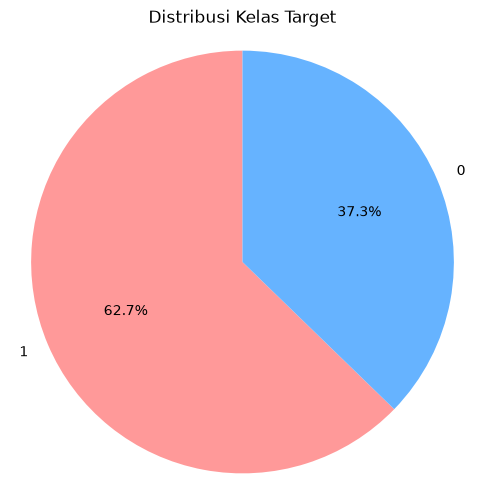

In [14]:
plt.figure(figsize=(6,6))
plt.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Distribusi Kelas Target")
plt.axis('equal')
plt.show()

#### *B. Inspeksi Distribusi Kelas Fitur*

In [15]:
def check_value(cols, top_n=1):
    for col in cols:
        print(f"Kolom: {col}")
        print(dataset[col].value_counts().head(top_n))
        print("-" * 40)
        print()

check_value(all_feature, top_n=1)

Kolom: radius_worst
radius_worst
12.36    5
Name: count, dtype: int64
----------------------------------------

Kolom: texture_worst
texture_worst
27.26    3
Name: count, dtype: int64
----------------------------------------

Kolom: perimeter_worst
perimeter_worst
117.7    3
Name: count, dtype: int64
----------------------------------------

Kolom: area_worst
area_worst
1269.0    2
Name: count, dtype: int64
----------------------------------------

Kolom: smoothness_worst
smoothness_worst
0.1312    4
Name: count, dtype: int64
----------------------------------------

Kolom: compactness_worst
compactness_worst
0.3416    3
Name: count, dtype: int64
----------------------------------------

Kolom: concavity_worst
concavity_worst
0.0    13
Name: count, dtype: int64
----------------------------------------

Kolom: concave points_worst
concave points_worst
0.0    13
Name: count, dtype: int64
----------------------------------------

Kolom: symmetry_worst
symmetry_worst
0.3196    3
Name: coun

### 7. Bivariate Analysis

#### *Inspeksi Distribysi Fitur berdasarkan Target*

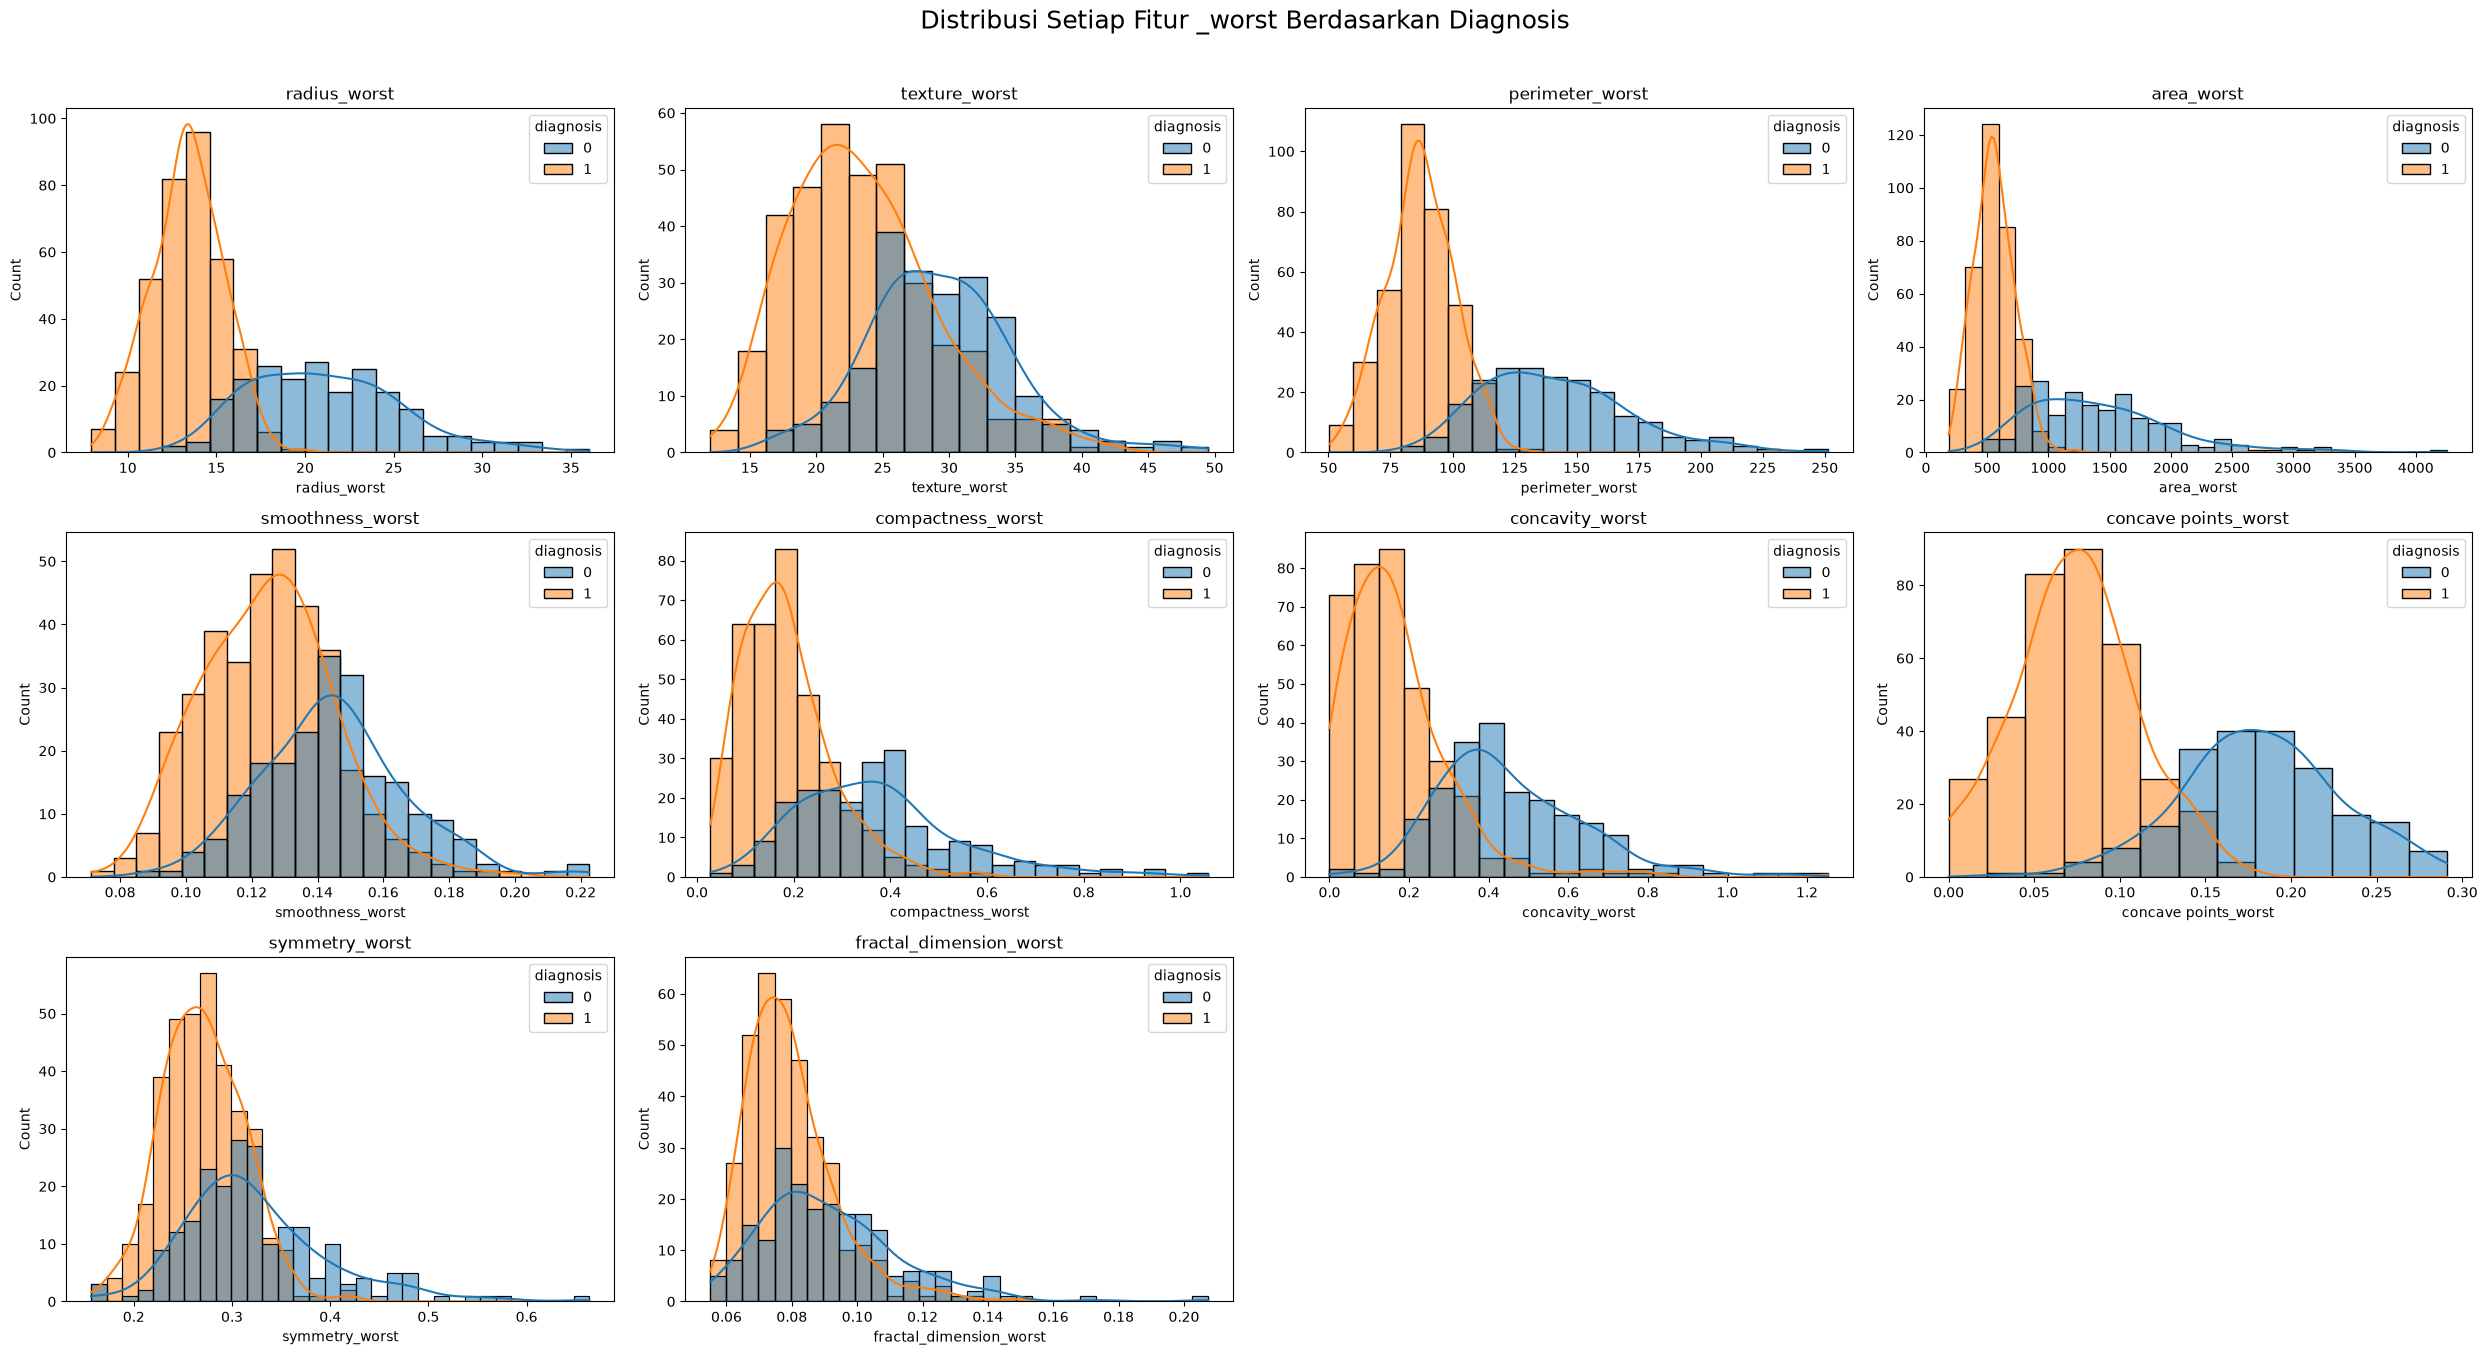

In [16]:
plt.figure(figsize=(25, 22))
for i, col in enumerate(all_feature): 
    plt.subplot(5, 4, i+1)
    sns.histplot(data=dataset_clean, x=col, hue='diagnosis', kde=True)  
    plt.title(f'{col}')

plt.suptitle("Distribusi Setiap Fitur _worst Berdasarkan Diagnosis", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])  
plt.show()

### 8. Inspeksi Korelasi

#### *a. Mutual Information*

In [19]:
def mutual_information_binned(x, y, bins=8, method='quantile', eps=1e-12):
    xs = pd.Series(x).astype(float)
    yb = pd.Series(y).astype(int)  

    if method == 'quantile':
        cats = pd.qcut(xs, q=bins, duplicates='drop')
    elif method == 'fd':  
        xnp = xs.values
        q75, q25 = np.percentile(xnp, [75, 25])
        iqr = q75 - q25
        n = len(xnp)
        bw = 2 * iqr / (n**(1/3) + 1e-12)
        nb = int(np.clip(np.ceil((xnp.max() - xnp.min()) / (bw + 1e-12)), 5, 30))
        cats = pd.cut(xs, bins=nb, include_lowest=True)
    else:
        raise ValueError("method harus 'quantile' atau 'fd'")

    codes = cats.cat.codes  
    ct = pd.crosstab(codes, yb, dropna=False).astype(float)

    Pxy = ct.values
    Pxy = Pxy / Pxy.sum()
    Px = Pxy.sum(axis=1, keepdims=True)
    Py = Pxy.sum(axis=0, keepdims=True)

    mi = np.sum(Pxy * (np.log2(Pxy + eps) - np.log2(Px + eps) - np.log2(Py + eps)))
    return float(mi)

fitur  = dataset[all_feature]                
target = dataset["diagnosis"].astype(int).values   

mi_scores = {col: mutual_information_binned(fitur[col].values, target, bins=8, method='quantile')
             for col in fitur.columns}

mi_df = (pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
         .sort_values(by="Mutual Information", ascending=False))

C:\Users\nizam\AppData\Local\Temp\ipykernel_5400\437729977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
C:\Users\nizam\AppData\Local\Temp\ipykernel_5400\437729977.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


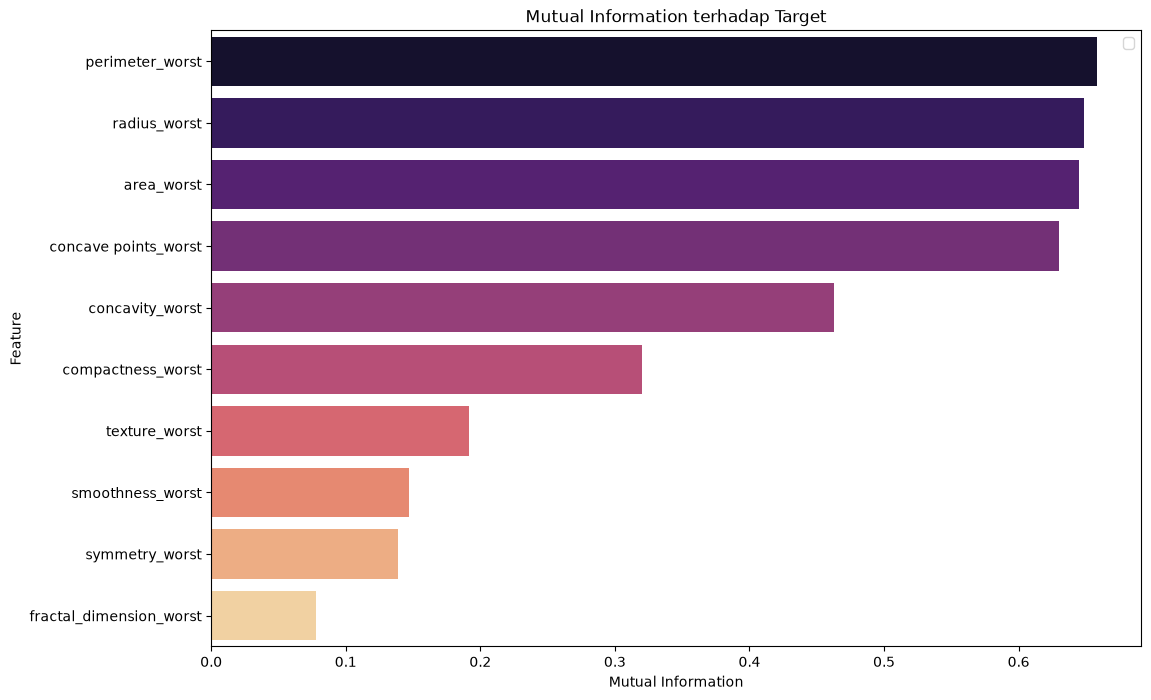

In [20]:
plt.figure(figsize=(12,8))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information terhadap Target")
plt.legend()
plt.show()

In [21]:
mi_df

,Feature,Mutual Information
2,perimeter_worst,0.658164
0,radius_worst,0.648558
3,area_worst,0.644725
7,concave points_worst,0.629712
6,concavity_worst,0.462751
5,compactness_worst,0.319827
1,texture_worst,0.191431
4,smoothness_worst,0.146954
8,symmetry_worst,0.138902
9,fractal_dimension_worst,0.078048


#### *b. Method Kendall*

In [22]:
def kendall_tau(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    concordant = 0
    discordant = 0
    n = len(x)
    for i in range(n-1):
        xi, yi = x[i], y[i]
        for j in range(i+1, n):
            prod = (xi - x[j]) * (yi - y[j])
            if prod > 0:
                concordant += 1
            elif prod < 0:
                discordant += 1
    denom = concordant + discordant
    if denom == 0:
        return 0.0
    return (concordant - discordant) / denom

features = all_feature  
y = dataset["diagnosis"].astype(int).values  

rows = []
for col in features:
    tau = kendall_tau(dataset[col].values, y)
    rows.append((col, tau))

kendall_df = (pd.DataFrame(rows, columns=["Feature", "Kendall_tau"])
                .sort_values("Kendall_tau", ascending=False)
                .reset_index(drop=True))

C:\Users\nizam\AppData\Local\Temp\ipykernel_5400\23836731.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=kendall_df, x="Kendall_tau", y="Feature",


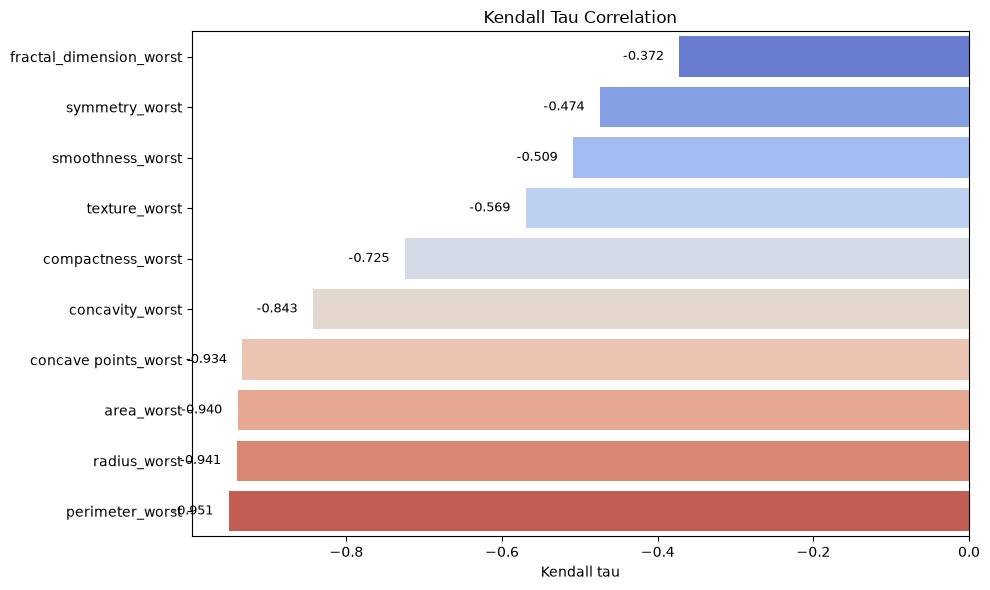

In [23]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=kendall_df, x="Kendall_tau", y="Feature",
                 palette="coolwarm", errorbar=None)
ax.set_title("Kendall Tau Correlation")
ax.set_xlabel("Kendall tau"); ax.set_ylabel("")

pad = 0.02
for i, v in enumerate(kendall_df["Kendall_tau"]):
    ax.text(v + (pad if v >= 0 else -pad), i, f"{v:.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

### 8. Inspeksi Outlier

<Axes: xlabel='diagnosis', ylabel='radius_worst'>

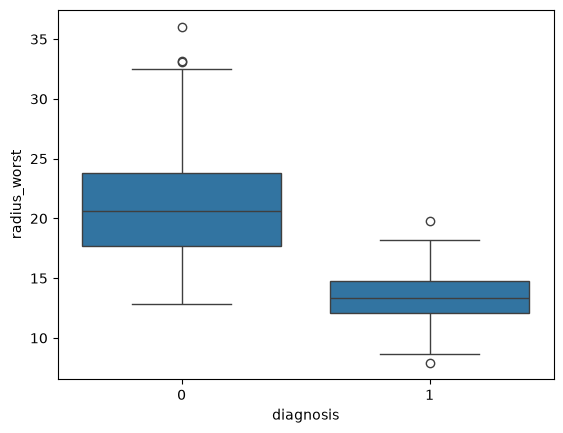

In [24]:
sns.boxplot(data=dataset_clean, x="diagnosis", y="radius_worst")

## ***B. Feature Selection***

In [25]:
feature_cols = ['perimeter_worst', 'radius_worst', 'area_worst', 'concave points_worst', 'concavity_worst']
feature_cols

['perimeter_worst',
 'radius_worst',
 'area_worst',
 'concave points_worst',
 'concavity_worst']

In [26]:
X_final = dataset_clean[feature_cols]
y_final = y

## ***C. Data Preprocessing***

In [27]:
def manual_standard_scaler(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    std = np.where (std == 0, 1, std)
    X_scaled = (X - mean) / std
    return X_scaled, mean, std

X_final = dataset_clean[feature_cols].values
y_final = y

X_scaled, scaler_mean, scaler_std = manual_standard_scaler(X_final)

## ***D. Stratified***

### 1. Stratified Splitting Data

In [28]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset_clean[target_column].unique():
        class_data = dataset_clean[dataset_clean[target_column] == class_value]
        class_data = class_data.sample(frac=1, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset_clean, "diagnosis")

### 2. Stratified K-Fold

## ***E. Feature Target Declaration***

In [29]:
X_train = dataset_training[feature_cols].to_numpy()
X_test = dataset_testing[feature_cols].to_numpy()

y_train = dataset_training["diagnosis"].to_numpy()
y_test = dataset_testing["diagnosis"].to_numpy()

# **III. Modeling**

## ***A. Model Application***

### 1. Model Class

In [30]:
class DecisionTreeClassifierManual:
    def __init__(self, max_depth=5, min_samples_split=2, max_features=None, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.tree = None

        if random_state is not None:
            np.random.seed(random_state)

    def _gini(self, y):
        m = len(y)
        if m == 0:
            return 0
        p1 = np.sum(y == 1) / m
        p0 = 1 - p1
        return 1 - p0**2 - p1**2
    
    def _best_split(self, X, y, feature_indices):
        m, n = X.shape
        best_gini = float('inf')
        best_idx, best_thr = None, None

        for idx in feature_indices:
            thresholds = np.unique(X[:, idx])
            for thr in thresholds:
                left_mask = X[:, idx] <= thr
                right_mask = ~left_mask

                if np.sum(left_mask) < self.min_samples_split or np.sum(right_mask) < self.min_samples_split:
                    continue

                gini_left = self._gini(y[left_mask])
                gini_right = self._gini(y[right_mask])
                gini_split = (np.sum(left_mask) * gini_left + np.sum(right_mask) * gini_right) / m

                if gini_split < best_gini:
                    best_gini = gini_split
                    best_idx = idx
                    best_thr = thr

        return best_idx, best_thr
    
    def _build_tree(self, X, y, depth=0):
        node = {'leaf': False}
        if (depth >= self.max_depth or 
            len(set(y)) == 1 or 
            len(y) < self.min_samples_split):
            node['leaf'] = True
            node['value'] = int(np.mean(y) >= 0.5)

            node['prob'] = np.mean(y)
            return node

        n_features = X.shape[1]
        if self.max_features is None:
            feature_indices = np.arange(n_features)
        else:
            feature_indices = np.random.choice(n_features, size=self.max_features, replace=False)
            idx, thr = self._best_split(X, y, feature_indices)
            if idx is None:
                node['leaf'] = True
                node['value'] = int(np.mean(y) >= 0.5)
                node['prob'] = np.mean(y)
                return node

            left_mask = X[:, idx] <= thr
            right_mask = ~left_mask

            node['feature_index'] = idx
            node['threshold'] = thr
            node['left'] = self._build_tree(X[left_mask], y[left_mask], depth + 1)
            node['right'] = self._build_tree(X[right_mask], y[right_mask], depth + 1)

            return node
        
    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values

        self.n_features_in_ = X.shape[1]
        self.tree = self._build_tree(X, y)

    def _predict_sample(self, x, tree):
        if tree['leaf']:
            return tree['value']
        if x[tree['feature_index']] <= tree['threshold']:
            return self._predict_sample(x, tree['left'])
        else:
            return self._predict_sample(x, tree['right'])
        
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        return np.array([self._predict_sample(x, self.tree) for x in X])
    
    def _predict_proba_sample(self, x, tree):
        if tree['leaf']:
            return tree['prob']
        if x[tree['feature_index']] <= tree['threshold']:
            return self._predict_proba_sample(x, tree['left'])
        else:
            return self._predict_proba_sample(x, tree['right'])
        
    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        probas = np.array([self._predict_proba_sample(x, self.tree) for x in X])
        return np.vstack([1 - probas, probas]).T

In [31]:
class RandomForestClassifierManual:
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=2, max_features='sqrt', bootstrap=True, random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.trees = []

        if random_state is not None:
            np.random.seed(random_state)

    def _get_max_features(self, n_features):
        if self.max_features == 'sqrt':
            return int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            return int(np.log2(n_features))
        elif isinstance(self.max_features, int):
            return min(self.max_features, n_features)
        elif isinstance(self.max_features, float):
            return int(self.max_features * n_features)
        else:
            return n_features
        
    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values

        n_samples, n_features = X.shape
        max_feat = self._get_max_features(n_features)

        self.trees = []

        for i in range(self.n_estimators):
            if self.random_state is not None:
                tree_seed = self.random_state + i
            else:
                tree_seed = None

            if self.bootstrap:
                indices = np.random.choice(n_samples, size=n_samples, replace=True)
                X_sample = X[indices]
                y_sample = y[indices]
            else:
                X_sample, y_sample = X, y

            tree = DecisionTreeClassifierManual(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=max_feat,
                random_state=tree_seed
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        if len(self.trees) == 0:
            raise Exception("Model blm dilatih")
        
        predictions = np.array([tree.predict(X) for tree in self.trees])
        final_pred = np.array([np.bincount(pred_row).argmax() for pred_row in predictions.T])
        return final_pred
    
    def predict_proba(self, X):
        if len(self.trees) == 0:
            raise Exception("Model belum dilatih!")
        
        probas = np.array([tree.predict_proba(X) for tree in self.trees])
        avg_probas = np.mean(probas, axis=0)
        return avg_probas
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [32]:
rf_model = RandomForestClassifierManual(
    n_estimators=5,         # kecilin dulu biar cepet & gampang debug
    max_depth=3,
    min_samples_split=5,
    max_features='sqrt',
    random_state=42
)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
accuracy_rf = rf_model.score(X_test, y_test)
print(f"\nAkurasi Random Forest: {accuracy_rf*100:.2f}%")

probas_rf = rf_model.predict_proba(X_test)
print(f"probabilitas (3 pertama):\n{probas_rf[:3]}")


Akurasi Random Forest: 96.52%
probabilitas (3 pertama):
[[1.   0.  ]
 [0.84 0.16]
 [1.   0.  ]]


In [33]:
y_train_pred = rf_model.predict(X_train)

## ***B. Visualisasi Model***

In [34]:
def plot_tree_manual(node, feature_names, ax, x=0.5, y=1.0, depth=0, max_depth=3, parent=None):
    if node is None or depth > max_depth:
        return

    if node['leaf']:
        pred = node['value']          
        prob = node.get('prob', None) 
        node_text = f"Leaf\nPred: {pred}"
        if prob is not None:
            node_text += f"\nP(1)={prob:.2f}"
        color = '#ff9999' if pred == 0 else '#66b3ff'
    else:
        feature_name = feature_names[node['feature_index']]
        thr = node['threshold']
        node_text = f"{feature_name} ≤ {thr:.2f}"
        color = '#d4e157'

    ax.text(x, y, node_text, ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=color), fontsize=8)

    if parent is not None:
        ax.annotate('', xy=(x, y), xytext=parent,
                    arrowprops=dict(arrowstyle="->", color='black'))

    if not node['leaf'] and depth < max_depth:
        left_x  = x - 0.5**(depth+2)
        right_x = x + 0.5**(depth+2)
        next_y = y - 0.2

        plot_tree_manual(node['left'],  feature_names, ax, x=left_x,  y=next_y,
                         depth=depth+1, max_depth=max_depth, parent=(x, y))
        plot_tree_manual(node['right'], feature_names, ax, x=right_x, y=next_y,
                         depth=depth+1, max_depth=max_depth, parent=(x, y))

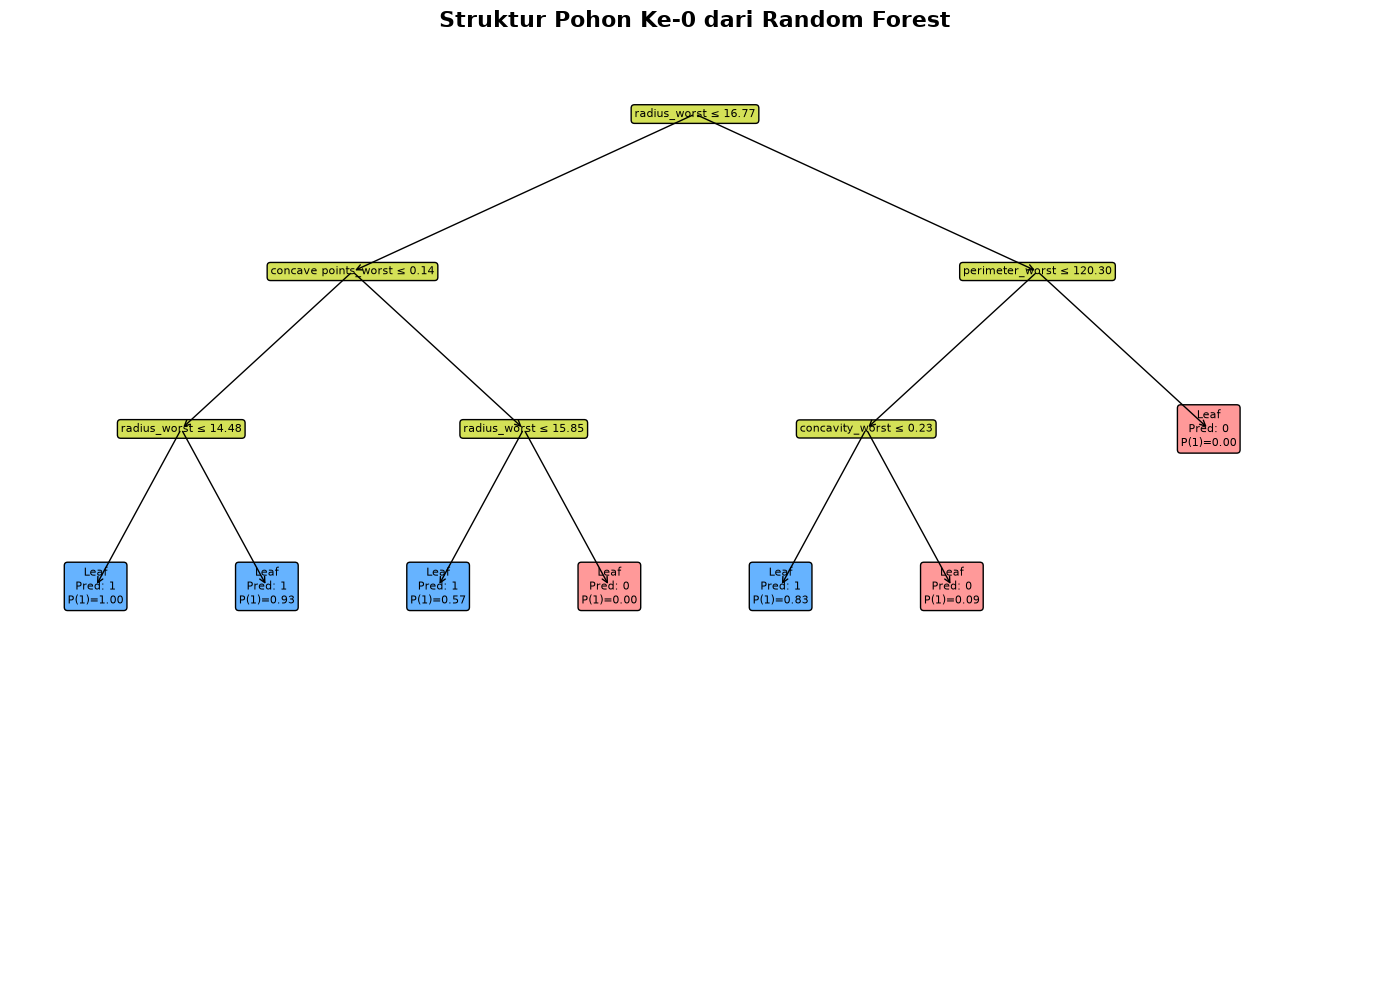

In [35]:
first_tree = rf_model.trees[0]
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 1); ax.set_ylim(-0.1, 1.1); ax.axis('off')
ax.set_title("Struktur Pohon Ke-0 dari Random Forest", fontsize=16, fontweight='bold')

plot_tree_manual(first_tree.tree, feature_cols, ax, x=0.5, y=1.0, max_depth=rf_model.max_depth)
plt.tight_layout()
plt.show()

In [36]:
def calculate_feature_usage(trees, feature_names):
    usage = {}  # tanpa defaultdict
    total_splits = 0

    for tree_obj in trees:
        # Ambil struktur dictionary pohon dari atribut .tree
        tree = tree_obj.tree  # ← INI KUNCI PERBAIKAN!
        
        stack = [tree]
        while stack:
            node = stack.pop()
            if not node.get('leaf', False) and 'feature_index' in node:
                feat_idx = node['feature_index']
                feat_name = feature_names[feat_idx]

                if feat_name not in usage:
                    usage[feat_name] = 0

                usage[feat_name] += 1
                total_splits += 1

                if 'left' in node:
                    stack.append(node['left'])
                if 'right' in node:
                    stack.append(node['right'])

    # Konversi ke DataFrame
    df_usage = pd.DataFrame(list(usage.items()), columns=['Feature', 'UsageCount'])
    if total_splits > 0:
        df_usage['Importance'] = df_usage['UsageCount'] / total_splits
    else:
        df_usage['Importance'] = 0.0
    df_usage = df_usage.sort_values('Importance', ascending=False).reset_index(drop=True)
    return df_usage

C:\Users\nizam\AppData\Local\Temp\ipykernel_5400\400472537.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')


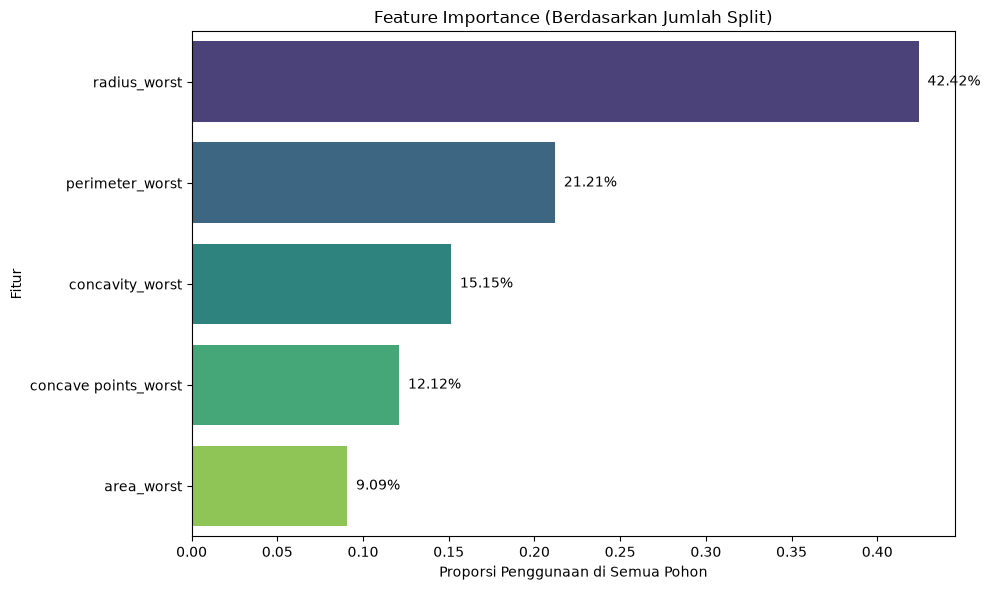


=== Feature Importance ===
                Feature  UsageCount  Importance
0          radius_worst          14    0.424242
1       perimeter_worst           7    0.212121
2       concavity_worst           5    0.151515
3  concave points_worst           4    0.121212
4            area_worst           3    0.090909


In [37]:
feat_imp_df = calculate_feature_usage(rf_model.trees, feature_cols)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Berdasarkan Jumlah Split)')
plt.xlabel('Proporsi Penggunaan di Semua Pohon')
plt.ylabel('Fitur')
for i, v in enumerate(feat_imp_df['Importance']):
    plt.text(v + 0.005, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()

print("\n=== Feature Importance ===")
print(feat_imp_df)

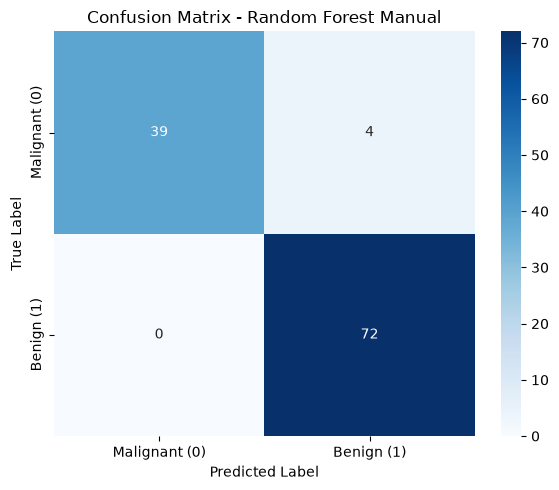

In [38]:
def manual_confusion_matrix(y_true, y_pred, labels=[0,1]):
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[labels.index(true), labels.index(pred)] += 1
    return cm

cm = manual_confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
plt.title('Confusion Matrix - Random Forest Manual')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

C:\Users\nizam\AppData\Local\Temp\ipykernel_5400\1994285187.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_proba, x='True_Label', y='Prob_Benign', palette=['#ff9999','#66b3ff'])


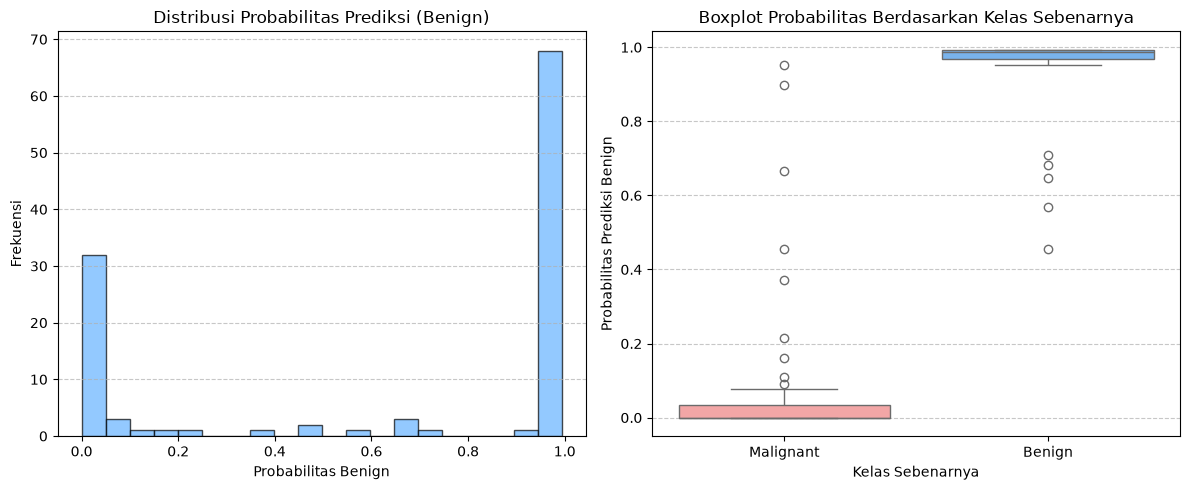

In [39]:
probas_rf = rf_model.predict_proba(X_test)  # shape: (n_samples, 2)

plt.figure(figsize=(12,5))

# Probabilitas Benign (kelas 1)
plt.subplot(1,2,1)
plt.hist(probas_rf[:,1], bins=20, color='#66b3ff', edgecolor='black', alpha=0.7)
plt.title('Distribusi Probabilitas Prediksi (Benign)')
plt.xlabel('Probabilitas Benign')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot probabilitas per kelas sebenarnya
plt.subplot(1,2,2)
df_proba = pd.DataFrame({
    'True_Label': ['Malignant' if y==0 else 'Benign' for y in y_test],
    'Prob_Benign': probas_rf[:,1]
})
sns.boxplot(data=df_proba, x='True_Label', y='Prob_Benign', palette=['#ff9999','#66b3ff'])
plt.title('Boxplot Probabilitas Berdasarkan Kelas Sebenarnya')
plt.xlabel('Kelas Sebenarnya')
plt.ylabel('Probabilitas Prediksi Benign')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## ***C. Evaluasi Model***

### 1. Confusion Matrix

In [40]:
def evaluation_metric(y_true, y_pred, average="macro"):
    accuracy_list, precision_list, recall_list, f1_list = [], [], [], []
    labels = np.unique(y_true)

    for label in labels:
        TP = np.sum((y_true == label) & (y_pred == label))
        FP = np.sum((y_true != label) & (y_pred == label))
        TN = np.sum((y_true != label) & (y_pred != label))
        FN = np.sum((y_true == label) & (y_pred != label))

        accuracy = (TP + TN) / (TP + TN + FP + FN) * 100 if (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

        accuracy_list.append(accuracy)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1_score)

    if average == 'macro':
        accuracy = np.mean(accuracy_list)
        precision = np.mean(precision_list)
        recall = np.mean(recall_list)
        f1_score = np.mean(f1_list)

    elif average == 'micro':
        TP = np.sum(y_true == y_pred)
        FP = np.sum((y_true != y_pred) & (y_pred != y_true))
        TN = np.sum(y_true == y_pred)
        FN = np.sum((y_true == y_pred) & (y_true != y_pred))

        accuracy = TP / len(y_true) * 100 if len(y_true) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return accuracy, precision, recall, f1_score

In [41]:
accuracy_train, precision_train, recall_train, f1_train = evaluation_metric(y_train, y_train_pred, average='micro')
print(f"Akurasi Train: {accuracy_train:.2f}")
print(f"Presisi Train: {precision_train:.2f}")
print(f"Recall Train: {recall_train:.2f}")
print(f"F1 Score Train: {f1_train:.2f}")

Akurasi Train: 95.37
Presisi Train: 0.95
Recall Train: 1.00
F1 Score Train: 0.98


In [42]:
accuracy_test, precision_test, recall_test, f1_test = evaluation_metric(y_test, y_pred_rf, average='micro')
print(f"Akurasi Train: {accuracy_test:.2f}")
print(f"Presisi Train: {precision_test:.2f}")
print(f"Recall Train: {recall_test:.2f}")
print(f"F1 Score Train: {f1_test:.2f}")

Akurasi Train: 96.52
Presisi Train: 0.97
Recall Train: 1.00
F1 Score Train: 0.98


### 2. Bias and Variance Model

In [43]:
def bias_variance(y_true_train, y_pred_train, y_true_test, y_pred_test):
    acc_train = np.mean(y_true_train == y_pred_train)
    acc_test = np.mean(y_true_test == y_pred_test)

    error_train = 1 - acc_train
    error_test = 1 - acc_test

    bias = error_train
    variance = error_test - error_train

    return bias, variance

Bias: 0.0463
Variance: -0.0115


C:\Users\nizam\AppData\Local\Temp\ipykernel_5400\277724114.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Bias", "Variance"], y=[bias, variance], palette='coolwarm')


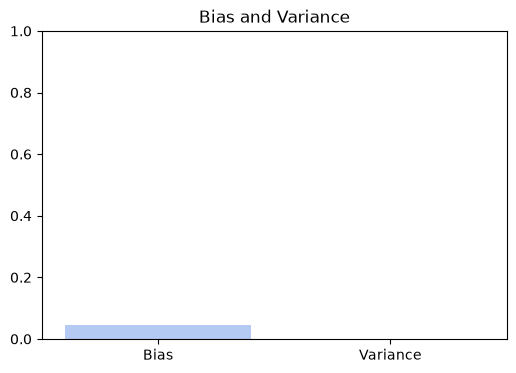

In [44]:
bias, variance = bias_variance(y_train, y_train_pred, y_test, y_pred_rf)

print("Bias:", round(bias, 4))
print("Variance:", round(variance, 4))

plt.figure(figsize=(6, 4))
sns.barplot(x=["Bias", "Variance"], y=[bias, variance], palette='coolwarm')
plt.title("Bias and Variance")
plt.ylim(0,1)
plt.show()

### 3. K-Fold Cross Validation

In [45]:
def stratified_k_fold(X, y, model, k=5):
    classes = np.unique(y)
    folds = [[] for _ in range(k)]

    for cls in classes:
        idx = np.where(y == cls)[0]
        np.random.shuffle(idx)
        split = np.array_split(idx, k)
        for i in range(k):
            folds[i].extend(split[i])

    accs = []
    for i in range(k):
        test_idx = np.array(folds[i])
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])  # ← FIX disini!

        model.fit(X[train_idx], y[train_idx])
        
        y_pred = model.predict(X[test_idx])
        
        acc, _, _, _ = evaluation_metric(y[test_idx], y_pred, average='micro')
        accs.append(acc)
        print(f"Fold {i+1}: Akurasi = {acc:.2f}%")

    mean_acc = np.mean(accs)
    std_acc = np.std(accs)

    print(f"\n📊 Rata-rata Akurasi: {mean_acc:.2f}%")
    print(f"📈 Standar Deviasi: {std_acc:.4f}")

    return mean_acc, std_acc

In [46]:
rf_simple = RandomForestClassifierManual(
    n_estimators=5,
    max_depth=3,
    min_samples_split=5,
    max_features='sqrt',
    random_state=42
)

print("\n" + "="*50)
print("STRATIFIED K-FOLD CROSS VALIDATION")
print("="*50)

avg_acc, std_acc = stratified_k_fold(X_scaled, y_final, rf_simple, k=5)


STRATIFIED K-FOLD CROSS VALIDATION
Fold 1: Akurasi = 92.17%
Fold 2: Akurasi = 97.39%
Fold 3: Akurasi = 92.04%
Fold 4: Akurasi = 92.04%
Fold 5: Akurasi = 93.81%

📊 Rata-rata Akurasi: 93.49%
📈 Standar Deviasi: 2.0632


## ***D. GUI***

In [47]:
def predict_from_gui():
    try:
        inputs = []
        for entry in entries:
            val = float(entry.get())
            inputs.append(val)

        X_input = np.array(inputs).reshape(1, -1)

        X_scaled_input = (X_input - scaler_mean) / scaler_std

        pred = rf_model.predict(X_scaled_input)[0]
        proba = rf_model.predict_proba(X_scaled_input)[0]

        diagnosis = "Benign (Jinak)" if pred == 1 else "Malignant (Ganas)"
        confidence = proba[1] if pred == 1 else proba[0]

        result_label.config(
            text=f"Prediksi: {diagnosis}\nConfidence: {confidence:.2%}",
            fg='green' if pred == 1 else 'red'
        )

    except ValueError:
        result_label.config(text="Error: Masukkan angka valid!", fg='red')
    except Exception as e:
        result_label.config(text=f"Error: {str(e)}", fg='red')

root = tk.Tk()
root.title("Breast Cancer Prediction")
root.geometry("500x550")
root.configure(bg='#f5f5f5')

title = tk.Label(root, text="Prediksi Kanker Payudara", font=("Helvetica", 16, "bold"), bg='#f5f5f5')
title.pack(pady=20)

input_frame = tk.Frame(root, bg='#f5f5f5')
input_frame.pack(pady=10)

feature_names = ['Perimeter Worst', 'Radius Worst', 'Area Worst',
                 'Concave Points Worst', 'Concavity Worst']
entries = []

for i, name in enumerate(feature_names):
    row = tk.Frame(input_frame, bg='#f5f5f5')
    row.pack(pady=5, fill='x', padx=30)

    label = tk.Label(row, text=name + ":", width=20, anchor='w', bg='#f5f5f5', font=("Arial", 10))
    label.pack(side='left')

    entry = tk.Entry(row, width=15, font=("Arial", 10))
    entry.pack(side='right')
    entries.append(entry)

    defaults = [100.0, 20.0, 1000.0, 0.1, 0.3]
    entry.insert(0, str(defaults[i]))

predict_btn = tk.Button(root, text="PREDIKSI", command=predict_from_gui,
                        bg='#4CAF50', fg='white', font=("Arial", 12, "bold"),
                        relief='raised', padx=20, pady=8)
predict_btn.pack(pady=20)

result_label = tk.Label(root, text="Hasil akan muncul di sini", font=("Arial", 12),
                        bg='#f5f5f5', fg='black', wraplength=400, justify='center')
result_label.pack(pady=20)

footer = tk.Label(root, text="© 2025 Breast Cancer Predictor",
                  font=("Arial", 8), bg='#f5f5f5', fg='#888')
footer.pack(side='bottom', pady=10)

root.mainloop()